# **Emotion Detection using Bi-Directional LSTM**

### **Project Objective**

The objective of this project is to build a **fine-grained emotion detection system** using a **Bi-Directional LSTM (BiLSTM)** model to classify text into emotional categories such as joy, anger, fear, sadness, and related affective states. The goal is to move beyond simple positive–negative sentiment analysis and develop a contextual sequence model that can detect nuanced emotional meaning in text. This project demonstrates how BiLSTM architectures can be applied to real-world NLP systems such as social listening platforms, customer feedback analytics, mental health support tools, conversational AI, and content moderation pipelines.

### **Dataset Used**

The dataset used in this project is based on the **Emotions Dataset for NLP**, available at:

**Dataset Link:** https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

This dataset typically contains short text samples paired with fine-grained emotion labels. Each record generally includes:

- **text / statement / sentence** → the raw textual input  
- **emotion / label** → the target emotional category  

In this notebook, the dataset is used as the core labeled corpus for supervised multi-class text classification. The workflow includes:

- loading and inspecting the raw emotion-labeled text records  
- standardizing text and label columns  
- cleaning and normalizing text while preserving emotion-bearing language  
- analyzing class distribution and text length patterns  
- tokenizing text into sequences  
- preparing padded inputs for sequence modeling  
- training a **BiLSTM classifier** for multi-class emotion recognition  
- evaluating the model using **accuracy, precision, recall, weighted F1-score, confusion matrix, and misclassification analysis**  
- exporting sample outputs and building a reusable inference utility  

Because fine-grained emotion detection requires contextual understanding and subtle distinction between similar emotions, the dataset is especially suitable for BiLSTM-based sequence modeling.

### **Project Summary**

This project develops an end-to-end **emotion classification pipeline** using a **Bi-Directional LSTM** model. The notebook begins by loading and profiling the emotion dataset, examining label balance, text length distributions, and data quality. It then cleans the raw text, tokenizes the sequences, pads them to a fixed length, and creates train, validation, and test splits for robust experimentation.

The core model uses an embedding layer followed by a **BiLSTM encoder**, allowing the system to read text in both forward and backward directions. This is important for emotion detection because emotional meaning often depends on the context of words before and after key phrases. A dense classification head is then used to predict the most likely emotion class.

The notebook emphasizes practical evaluation beyond simple accuracy. It includes weighted precision, recall, F1-score, confidence-based prediction analysis, detailed confusion matrix inspection, and category-specific error analysis. This makes the project more realistic and useful for portfolio presentation, especially because fine-grained emotion categories are often confused by simpler models.

The final notebook also includes model saving and reload validation, prediction export, reusable inference functions, and an optional deployment demo section. As a result, the project serves as both a strong BiLSTM portfolio project and a realistic implementation of fine-grained emotion-aware NLP.

### **Key Highlights**

- Built a **fine-grained emotion detection system** using **Bi-Directional LSTM**.
- Used the **Emotions Dataset for NLP** as the supervised corpus for multi-class emotion classification.
- Performed detailed **dataset exploration**, including class balance and text length analysis.
- Implemented **text cleaning, tokenization, vocabulary building, and padded sequence preprocessing**.
- Built a **BiLSTM-based multi-class classifier** for contextual emotion detection.
- Evaluated the model using **accuracy, precision, recall, weighted F1-score, confusion matrix, and confidence analysis**.
- Added **misclassification analysis** to identify confusion between similar emotions.
- Included **sample outputs**, **model save/reload validation**, and an optional **deployment demo** section.
- Preserved a modular workflow so the notebook can be extended into social media monitoring, mental-health NLP, or emotional chatbot systems.


### **Install Required Libraries**

In [1]:
!pip -q install -U pandas numpy matplotlib scikit-learn nltk ipywidgets tensorflow keras

### **Import Core Libraries**

In [2]:
import os
import gc
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

### **Notebook Display Settings**

In [3]:
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### **Set Reproducibility Seed**

In [4]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


### **Create Project Folders**

In [5]:
PROJECT_DIR = Path("./emotion_detection_bilstm_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "saved_model"
PRED_DIR = PROJECT_DIR / "predictions"

for folder in [PROJECT_DIR, ARTIFACT_DIR, MODEL_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


### **Define Project Configuration**

In [6]:
DATA_ROOT = Path("./emotion_dataset_data")
DATA_FILE = DATA_ROOT / "emotion_dataset.csv"

MAX_VOCAB_SIZE = 30000
MAX_SEQ_LEN = 60
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.30
BATCH_SIZE = 32
EPOCHS = 5
MIN_CLASS_COUNT = 2

print("Configuration ready.")

Configuration ready.


### **State the Real-World Problem**

In [7]:
problem_statement = '''
Organizations increasingly need systems that can detect not just sentiment, but specific emotions such as joy,
anger, fear, sadness, and surprise. Fine-grained emotion detection helps with brand monitoring, mental health
screening support, emotionally aware chatbots, and safety moderation. This project addresses that problem using
a Bi-Directional LSTM model for multi-class emotion classification.
'''
print(problem_statement)


Organizations increasingly need systems that can detect not just sentiment, but specific emotions such as joy,
anger, fear, sadness, and surprise. Fine-grained emotion detection helps with brand monitoring, mental health
screening support, emotionally aware chatbots, and safety moderation. This project addresses that problem using
a Bi-Directional LSTM model for multi-class emotion classification.



### **Show Expected Dataset Structure**

In [8]:
expected_structure = '''
emotion_dataset_data/
└── emotion_dataset.csv

Common columns may include:
- text
- emotion
'''
print(expected_structure)


emotion_dataset_data/
└── emotion_dataset.csv

Common columns may include:
- text
- emotion



### **Create a Small Placeholder Dataset if Missing**

In [9]:
if not DATA_FILE.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    sample_df = pd.DataFrame({
        "text": [
            "I am feeling extremely happy and excited today",
            "This makes me so angry and frustrated",
            "I feel scared about what might happen next",
            "I am deeply sad and heartbroken right now",
            "I am surprised by the news I just heard",
            "I feel calm and peaceful this morning",
            "I am worried and anxious about the exam",
            "This success makes me joyful and proud",
            "I feel lonely and miserable tonight",
            "That noise in the dark makes me fearful"
        ],
        "emotion": [
            "joy", "anger", "fear", "sadness", "surprise",
            "calm", "fear", "joy", "sadness", "fear"
        ]
    })

    sample_df.to_csv(DATA_FILE, index=False)
    print("Created a placeholder dataset for notebook structure.")
else:
    print("Dataset file already exists.")

Dataset file already exists.


### **Load the Emotion Dataset**

In [10]:
df = pd.read_csv(DATA_FILE)
print(df.shape)
df.head()

(10, 2)


,text,emotion
0,I am feeling extremely happy and excited today,joy
1,This makes me so angry and frustrated,anger
2,I feel scared about what might happen next,fear
3,I am deeply sad and heartbroken right now,sadness
4,I am surprised by the news I just heard,surprise


### **Inspect Dataset Columns**

In [11]:
df.columns.tolist()

['text', 'emotion']

### **Rename Columns to Standard Names**

In [12]:
column_map = {}
for col in df.columns:
    lower_col = col.lower()
    if "text" in lower_col or "sentence" in lower_col or "statement" in lower_col:
        column_map[col] = "text"
    elif "emotion" in lower_col or "label" in lower_col or "category" in lower_col:
        column_map[col] = "emotion"

df = df.rename(columns=column_map)
df.head()

,text,emotion
0,I am feeling extremely happy and excited today,joy
1,This makes me so angry and frustrated,anger
2,I feel scared about what might happen next,fear
3,I am deeply sad and heartbroken right now,sadness
4,I am surprised by the news I just heard,surprise


### **Check Missing Values**

In [13]:
df.isna().sum()

text       0
emotion    0
dtype: int64

### **Drop Missing Text or Emotion Rows**

In [14]:
df = df.dropna(subset=["text", "emotion"]).reset_index(drop=True)
print(df.shape)

(10, 2)


### **Inspect Emotion Distribution**

In [15]:
df["emotion"].value_counts()

emotion
fear        3
joy         2
sadness     2
anger       1
surprise    1
calm        1
Name: count, dtype: int64

### **Plot Emotion Distribution**

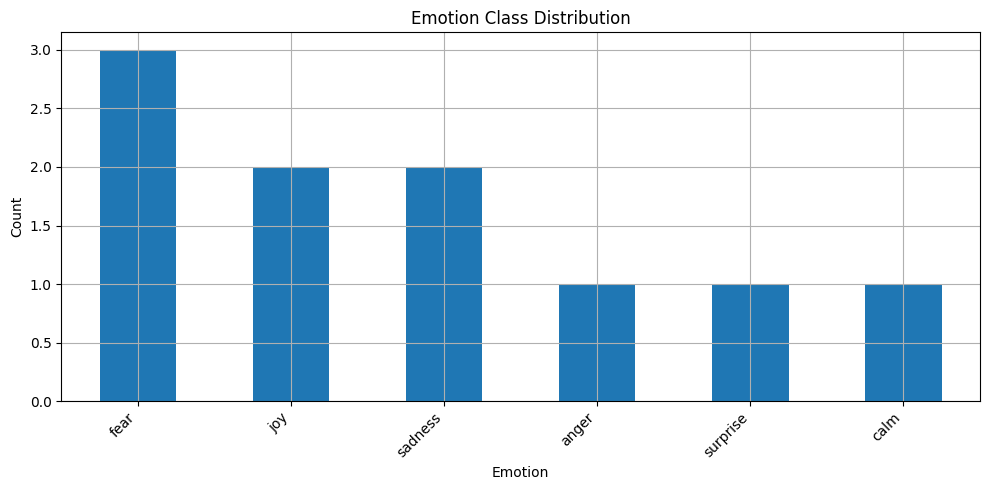

In [16]:
df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Text Length Features**

In [17]:
df["text_char_len"] = df["text"].astype(str).str.len()
df["text_word_len"] = df["text"].astype(str).str.split().str.len()
df[["text_char_len", "text_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
text_char_len,10.0,39.3,3.093003,35.0,37.25,39.0,40.5,46.0
text_word_len,10.0,7.6,0.843274,6.0,7.00,8.0,8.0,9.0


### **Plot Text Word Length Distribution**

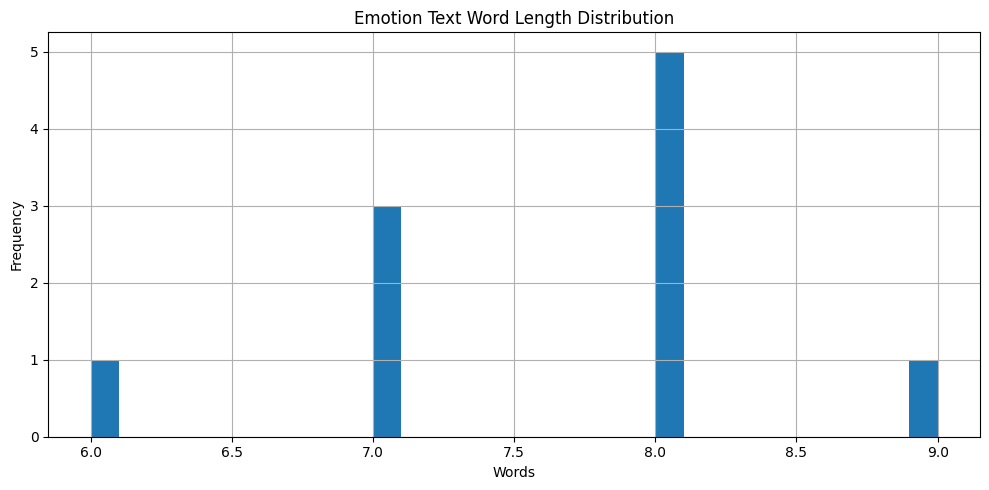

In [18]:
df["text_word_len"].hist(bins=30)
plt.title("Emotion Text Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Display Random Text Samples**

In [19]:
df.sample(min(5, len(df)), random_state=SEED)[["emotion", "text"]]

,emotion,text
8,sadness,I feel lonely and miserable tonight
1,anger,This makes me so angry and frustrated
5,calm,I feel calm and peaceful this morning
0,joy,I am feeling extremely happy and excited today
7,joy,This success makes me joyful and proud


### **Define Text Cleaning Function**

In [20]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **Clean Emotion Text**

In [21]:
df["text_clean"] = df["text"].apply(clean_text)
df[["text", "text_clean"]].head(3)

,text,text_clean
0,I am feeling extremely happy and excited today,i am feeling extremely happy and excited today
1,This makes me so angry and frustrated,this makes me so angry and frustrated
2,I feel scared about what might happen next,i feel scared about what might happen next


### **Estimate Vocabulary Size**

In [22]:
all_tokens = " ".join(df["text_clean"].tolist()).split()
vocab_size_est = len(set(all_tokens))
print("Estimated vocabulary size:", vocab_size_est)

Estimated vocabulary size: 49


### **Inspect Most Common Tokens**

In [23]:
pd.DataFrame(Counter(all_tokens).most_common(25), columns=["token", "count"])

,token,count
0,i,8
1,and,7
2,am,4
3,this,3
4,makes,3
5,me,3
6,feel,3
7,the,3
8,about,2
9,feeling,1


### **Filter Very Rare Classes if Needed**

In [24]:
label_counts = df["emotion"].value_counts()
valid_labels = label_counts[label_counts >= MIN_CLASS_COUNT].index.tolist()
df = df[df["emotion"].isin(valid_labels)].reset_index(drop=True)
print(df.shape)
print(df["emotion"].nunique(), "classes retained")

(7, 5)
3 classes retained


### **Recheck Emotion Distribution After Filtering**

In [25]:
df["emotion"].value_counts()

emotion
fear       3
joy        2
sadness    2
Name: count, dtype: int64

### **Encode Emotion Labels to Integers**

In [26]:
label_to_id = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
id_to_label = {idx: label for label, idx in label_to_id.items()}

df["label_id"] = df["emotion"].map(label_to_id)
df[["emotion", "label_id"]].drop_duplicates().sort_values("label_id")

,emotion,label_id
1,fear,0
0,joy,1
2,sadness,2


### **Compute Number of Classes**

In [27]:
num_classes = df["label_id"].nunique()
print("Number of classes:", num_classes)

Number of classes: 3


### **Initialize Tokenizer**

In [28]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text_clean"].tolist())
print("Tokenizer fitted successfully.")

Tokenizer fitted successfully.


### **Inspect Vocabulary Size after Tokenization**

In [29]:
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size used:", vocab_size)

Vocabulary size used: 40


### **Convert Text to Sequences**

In [30]:
df["text_seq"] = tokenizer.texts_to_sequences(df["text_clean"].tolist())
df[["text_clean", "text_seq"]].head(2)

,text_clean,text_seq
0,i am feeling extremely happy and excited today,"[2, 4, 10, 11, 12, 3, 13, 14]"
1,i feel scared about what might happen next,"[2, 5, 15, 6, 16, 17, 18, 19]"


### **Analyze Sequence Lengths**

In [31]:
seq_lengths = df["text_seq"].apply(len)
pd.Series(seq_lengths).describe()

count    7.000000
mean     7.571429
std      0.786796
min      6.000000
25%      7.500000
50%      8.000000
75%      8.000000
max      8.000000
Name: text_seq, dtype: float64

### **Plot Sequence Length Distribution**

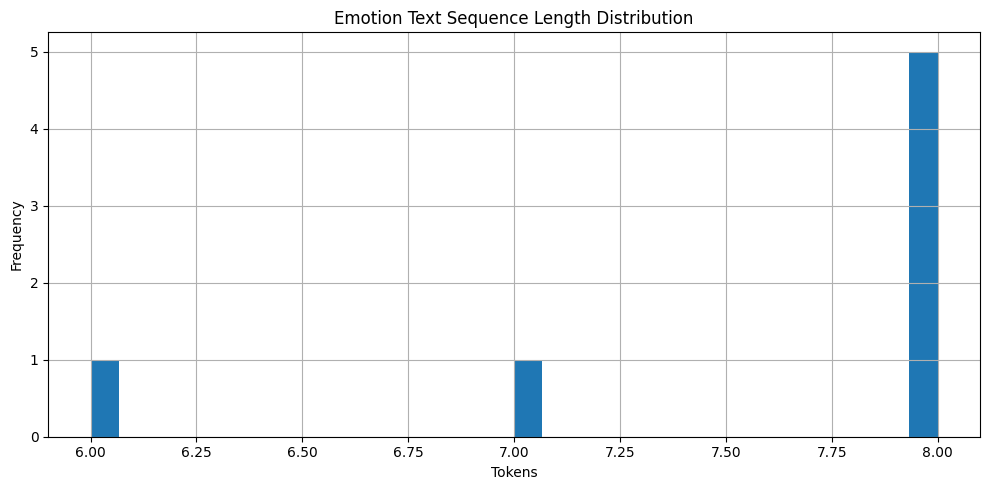

In [32]:
pd.Series(seq_lengths).hist(bins=30)
plt.title("Emotion Text Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Pad Sequences**

In [33]:
X = pad_sequences(
    df["text_seq"].tolist(),
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post"
)
X.shape

(7, 60)

### **Create Target Array**

In [34]:
y = df["label_id"].values
y[:10]

array([1, 0, 2, 0, 1, 2, 0], dtype=int64)

### **Create One-Hot Encoded Targets**

In [35]:
y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes)
y_onehot[:3]

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

### **Split into Train and Temp Sets**

In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_onehot,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)
print(X_train.shape, X_temp.shape)

(4, 60) (3, 60)


### **Split Temp into Validation and Test Sets**

In [37]:
temp_labels = np.argmax(y_temp, axis=1)

# Check whether stratified split is possible
temp_label_counts = pd.Series(temp_labels).value_counts()

if temp_label_counts.min() < 2:
    print("Some classes in temp set have fewer than 2 samples. Falling back to non-stratified split.")
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=None
    )
else:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_labels
    )

print(X_val.shape, X_test.shape)

Some classes in temp set have fewer than 2 samples. Falling back to non-stratified split.
(1, 60) (2, 60)


### **Create Metadata DataFrames for Validation and Test Analysis**

In [38]:
meta_labels = df["label_id"].values
meta_counts = pd.Series(meta_labels).value_counts()

if meta_counts.min() < 2:
    train_meta_df, temp_meta_df = train_test_split(
        df.reset_index(drop=True),
        test_size=0.30,
        random_state=SEED,
        stratify=None
    )
else:
    train_meta_df, temp_meta_df = train_test_split(
        df.reset_index(drop=True),
        test_size=0.30,
        random_state=SEED,
        stratify=df["label_id"]
    )

temp_meta_labels = temp_meta_df["label_id"].values
temp_meta_counts = pd.Series(temp_meta_labels).value_counts()

if temp_meta_counts.min() < 2:
    val_meta_df, test_meta_df = train_test_split(
        temp_meta_df.reset_index(drop=True),
        test_size=0.50,
        random_state=SEED,
        stratify=None
    )
else:
    val_meta_df, test_meta_df = train_test_split(
        temp_meta_df.reset_index(drop=True),
        test_size=0.50,
        random_state=SEED,
        stratify=temp_meta_labels
    )

val_meta_df = val_meta_df.reset_index(drop=True)
test_meta_df = test_meta_df.reset_index(drop=True)

print(val_meta_df.shape, test_meta_df.shape)

(1, 7) (2, 7)


### **Build the BiLSTM Emotion Model**

In [39]:
text_input = Input(shape=(MAX_SEQ_LEN,), name="emotion_text_input")
x = Embedding(vocab_size, EMBEDDING_DIM, name="embedding")(text_input)
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False), name="bilstm")(x)
x = Dropout(DROPOUT_RATE, name="dropout_1")(x)
x = Dense(128, activation="relu", name="dense_1")(x)
x = Dropout(0.20, name="dropout_2")(x)
output = Dense(num_classes, activation="softmax", name="emotion_output")(x)

model = Model(inputs=text_input, outputs=output, name="emotion_detection_bilstm_classifier")
model.summary()

Model: "emotion_detection_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ emotion_text_input (InputLayer)      │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 60, 128)             │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm (Bidirectional)               │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ emotion_output (Dense)               │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,835 (472.01 KB)

 Trainable params: 120,835 (472.01 KB)

 Non-trainable params: 0 (0.00 B)

### **Print a Simple Model Architecture Diagram**

In [40]:
architecture_diagram = '''
Emotion Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Dense Layers ─► Emotion Class
'''
print(architecture_diagram)


Emotion Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Dense Layers ─► Emotion Class



### **Compile the Model**

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### **Create Training Callbacks**

In [42]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )
]

print("Callbacks ready.")

Callbacks ready.


### **Train the Emotion Detection Model**

In [43]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 1.1008 - val_accuracy: 0.0000e+00 - val_loss: 1.1157 - learning_rate: 0.0010
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7500 - loss: 1.0873 - val_accuracy: 0.0000e+00 - val_loss: 1.1271 - learning_rate: 0.0010
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7500 - loss: 1.0828 - val_accuracy: 0.0000e+00 - val_loss: 1.1323 - learning_rate: 5.0000e-04


### **Convert Training History to DataFrame**

In [44]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.25,1.100845,0.0,1.115724,0.0010
1,0.75,1.087328,0.0,1.127100,0.0010
2,0.75,1.082766,0.0,1.132326,0.0005


### **Plot Training and Validation Loss**

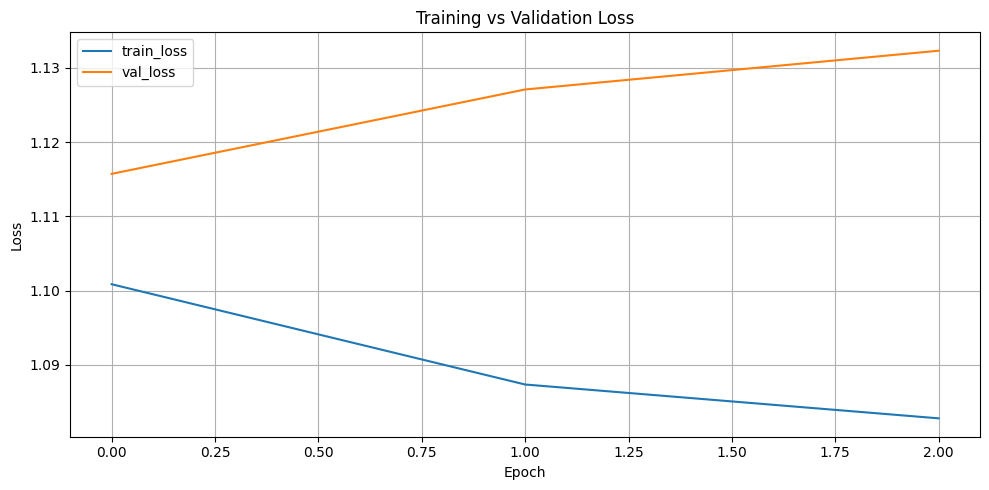

In [45]:
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training and Validation Accuracy**

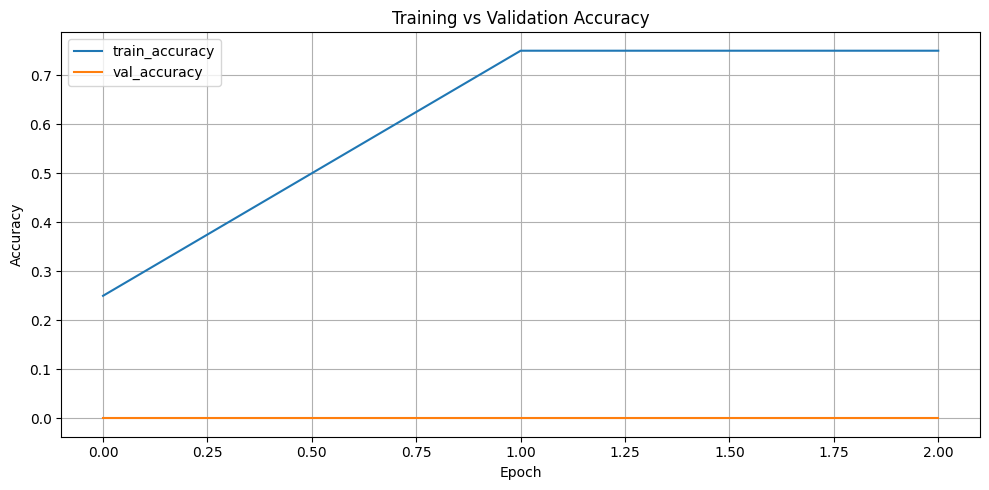

In [46]:
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate on the Test Set**

In [47]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print({"test_loss": round(float(test_loss), 4), "test_accuracy": round(float(test_accuracy), 4)})

{'test_loss': 1.0928, 'test_accuracy': 0.5}


### **Generate Test Predictions**

In [48]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print(y_pred[:10])
print(y_true[:10])

[0 0]
[0 1]


### **Compute Weighted Precision, Recall, and F1**

In [49]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

metrics_dict = {
    "accuracy": accuracy_score(y_true, y_pred),
    "weighted_precision": precision,
    "weighted_recall": recall,
    "weighted_f1_score": f1
}
metrics_dict

{'accuracy': 0.5,
 'weighted_precision': 0.25,
 'weighted_recall': 0.5,
 'weighted_f1_score': 0.3333333333333333}

### **Display Classification Report**

In [50]:
target_labels = sorted(id_to_label.keys())
target_names = [id_to_label[i] for i in target_labels]

print(
    classification_report(
        y_true,
        y_pred,
        labels=target_labels,
        target_names=target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        fear       0.50      1.00      0.67         1
         joy       0.00      0.00      0.00         1
     sadness       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.17      0.33      0.22         2
weighted avg       0.25      0.50      0.33         2



### **Create Confusion Matrix Table**

In [51]:
cm = confusion_matrix(y_true, y_pred, labels=target_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df

,fear,joy,sadness
fear,1,0,0
joy,1,0,0
sadness,0,0,0


### **Visualize Confusion Matrix**

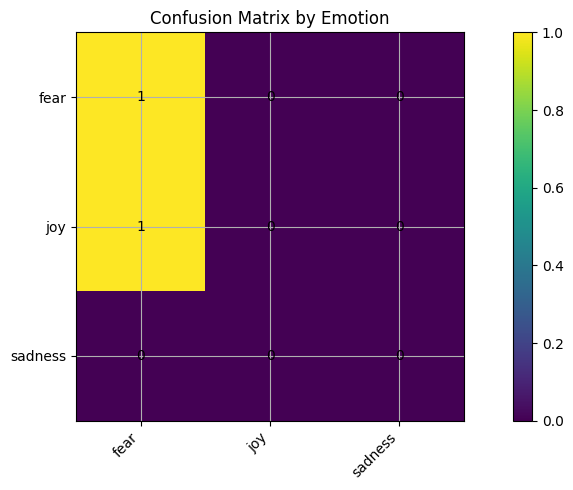

In [52]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix by Emotion")
plt.colorbar()
plt.xticks(range(len(target_names)), target_names, rotation=45, ha="right")
plt.yticks(range(len(target_names)), target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### **Create Prediction Analysis DataFrame**

In [53]:
prediction_df = test_meta_df.copy().reset_index(drop=True)
prediction_df["true_label_id"] = y_true
prediction_df["pred_label_id"] = y_pred
prediction_df["true_emotion"] = prediction_df["true_label_id"].map(id_to_label)
prediction_df["pred_emotion"] = prediction_df["pred_label_id"].map(id_to_label)
prediction_df["is_correct"] = (prediction_df["true_label_id"] == prediction_df["pred_label_id"]).astype(int)
prediction_df["confidence"] = y_pred_prob.max(axis=1)
prediction_df.head()

,text,emotion,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_emotion,pred_emotion,is_correct,confidence
0,That noise in the dark makes me fearful,fear,39,8,that noise in the dark makes me fearful,0,"[35, 36, 37, 7, 38, 8, 9, 39]",0,0,fear,fear,1,0.336933
1,I am feeling extremely happy and excited today,joy,46,8,i am feeling extremely happy and excited today,1,"[2, 4, 10, 11, 12, 3, 13, 14]",1,0,joy,fear,0,0.338086


### **Review Most Confident Correct Predictions**

In [54]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[False, False]).head(10)

,text,emotion,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_emotion,pred_emotion,is_correct,confidence
0,That noise in the dark makes me fearful,fear,39,8,that noise in the dark makes me fearful,0,"[35, 36, 37, 7, 38, 8, 9, 39]",0,0,fear,fear,1,0.336933
1,I am feeling extremely happy and excited today,joy,46,8,i am feeling extremely happy and excited today,1,"[2, 4, 10, 11, 12, 3, 13, 14]",1,0,joy,fear,0,0.338086


### **Review Most Confident Incorrect Predictions**

In [55]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[True, False]).head(10)

,text,emotion,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_emotion,pred_emotion,is_correct,confidence
1,I am feeling extremely happy and excited today,joy,46,8,i am feeling extremely happy and excited today,1,"[2, 4, 10, 11, 12, 3, 13, 14]",1,0,joy,fear,0,0.338086
0,That noise in the dark makes me fearful,fear,39,8,that noise in the dark makes me fearful,0,"[35, 36, 37, 7, 38, 8, 9, 39]",0,0,fear,fear,1,0.336933


### **Analyze Accuracy by Emotion Class**

In [56]:
prediction_df.groupby("true_emotion")["is_correct"].mean().sort_values()

true_emotion
joy     0.0
fear    1.0
Name: is_correct, dtype: float64

### **Plot Accuracy by Emotion Class**

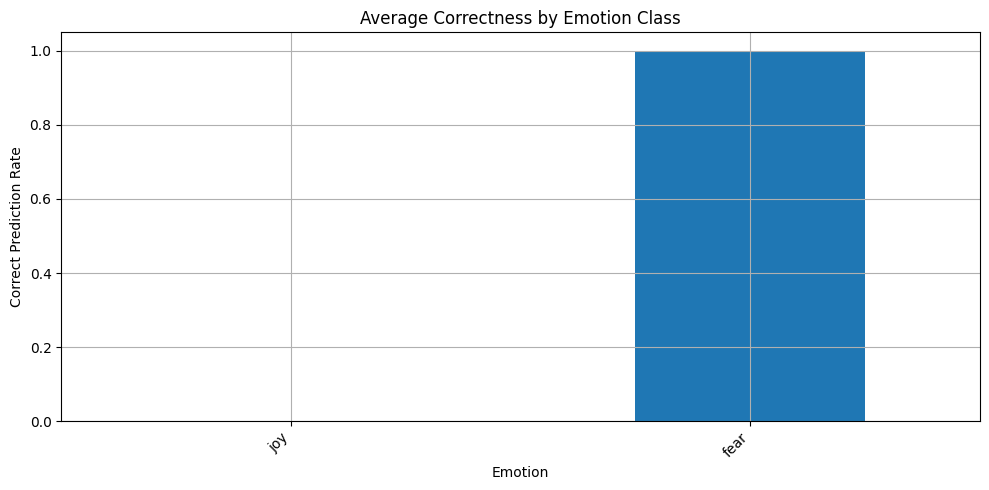

In [57]:
prediction_df.groupby("true_emotion")["is_correct"].mean().sort_values().plot(kind="bar")
plt.title("Average Correctness by Emotion Class")
plt.xlabel("Emotion")
plt.ylabel("Correct Prediction Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Misclassification Summary Table**

In [58]:
misclassified_df = prediction_df[prediction_df["is_correct"] == 0].copy()
misclassified_df[["text_clean", "true_emotion", "pred_emotion", "confidence"]].head(10)

,text_clean,true_emotion,pred_emotion,confidence
1,i am feeling extremely happy and excited today,joy,fear,0.338086


### **Create Inference Utility**

In [59]:
def predict_emotion(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
    probs = model.predict(pad, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_label = id_to_label[pred_id]
    confidence = float(np.max(probs))
    return {
        "predicted_emotion": pred_label,
        "confidence": confidence,
        "probabilities": {id_to_label[i]: float(probs[i]) for i in range(len(probs))}
    }

### **Test the Inference Utility**

In [60]:
predict_emotion(
    "I am feeling nervous and afraid about tomorrow"
)

{'predicted_emotion': 'fear',
 'confidence': 0.3394917845726013,
 'probabilities': {'fear': 0.3394917845726013,
  'joy': 0.33566081523895264,
  'sadness': 0.3248473107814789}}

### **Create Sample Output Table**

In [61]:
sample_outputs = []
for txt in test_meta_df["text_clean"].head(min(5, len(test_meta_df))).tolist():
    pred = predict_emotion(txt)
    sample_outputs.append({
        "text": txt,
        "predicted_emotion": pred["predicted_emotion"],
        "confidence": pred["confidence"]
    })

pd.DataFrame(sample_outputs)

,text,predicted_emotion,confidence
0,that noise in the dark makes me fearful,fear,0.336933
1,i am feeling extremely happy and excited today,fear,0.338086


### **Save Model Artifacts**

In [62]:
model.save(MODEL_DIR / "emotion_detection_bilstm_model.keras")
with open(ARTIFACT_DIR / "tokenizer_config.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.to_json(), f)

with open(ARTIFACT_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in id_to_label.items()}, f)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


### **Save Prediction Outputs**

In [63]:
prediction_df.to_csv(PRED_DIR / "emotion_prediction_analysis.csv", index=False)
history_df.to_csv(PRED_DIR / "emotion_training_history.csv", index=False)

print("Prediction outputs saved.")

Prediction outputs saved.


### **Reload the Saved Model**

In [64]:
reloaded_model = tf.keras.models.load_model(MODEL_DIR / "emotion_detection_bilstm_model.keras")
print("Reloaded model successfully.")

Reloaded model successfully.


### **Run Reload Validation**

In [65]:
reload_probs = reloaded_model.predict(X_test[:10], verbose=0)
reload_probs[:2]

array([[0.33693302, 0.33466113, 0.32840586],
       [0.3380859 , 0.33365104, 0.32826307]], dtype=float32)

### **Create Deployment Demo Function**

In [66]:
def emotion_demo(text):
    return predict_emotion(text)

### **Test Deployment Demo Function**

In [67]:
emotion_demo(
    "I am so happy and excited to see this result"
)

{'predicted_emotion': 'fear',
 'confidence': 0.3402351438999176,
 'probabilities': {'fear': 0.3402351438999176,
  'joy': 0.33491602540016174,
  'sadness': 0.32484880089759827}}

### **Create Optional Streamlit App Code**

In [68]:
streamlit_app_code = '''
import streamlit as st

st.title("Emotion Detection Demo")
text = st.text_area("Enter Text")

if st.button("Predict Emotion"):
    st.write("Load the saved model and display predicted emotion here.")
'''
print(streamlit_app_code)


import streamlit as st

st.title("Emotion Detection Demo")
text = st.text_area("Enter Text")

if st.button("Predict Emotion"):
    st.write("Load the saved model and display predicted emotion here.")



### **Final Project Summary for Notebook Report**

In [69]:
final_project_notes = {
    "project_title": "Emotion Detection using Bi-Directional LSTM",
    "dataset": "Emotions Dataset for NLP",
    "model_type": "BiLSTM",
    "core_goal": "Detect fine-grained emotions from text using contextual sequence modeling.",
    "deployment_ready": True,
    "includes_demo": True
}
final_project_notes

{'project_title': 'Emotion Detection using Bi-Directional LSTM',
 'dataset': 'Emotions Dataset for NLP',
 'model_type': 'BiLSTM',
 'core_goal': 'Detect fine-grained emotions from text using contextual sequence modeling.',
 'deployment_ready': True,
 'includes_demo': True}

### **Conclusion**

In [70]:
print(
    "This notebook built an end-to-end fine-grained emotion detection workflow with dataset analysis, "
    "text cleaning, tokenization, BiLSTM modeling, evaluation, misclassification analysis, "
    "and an optional deployment demo."
)

This notebook built an end-to-end fine-grained emotion detection workflow with dataset analysis, text cleaning, tokenization, BiLSTM modeling, evaluation, misclassification analysis, and an optional deployment demo.
